✅ Imagen generada y guardada exitosamente en: /content/drive/My Drive/Experimentos/final/models/climax_finetuned/climax_arquitectura.png


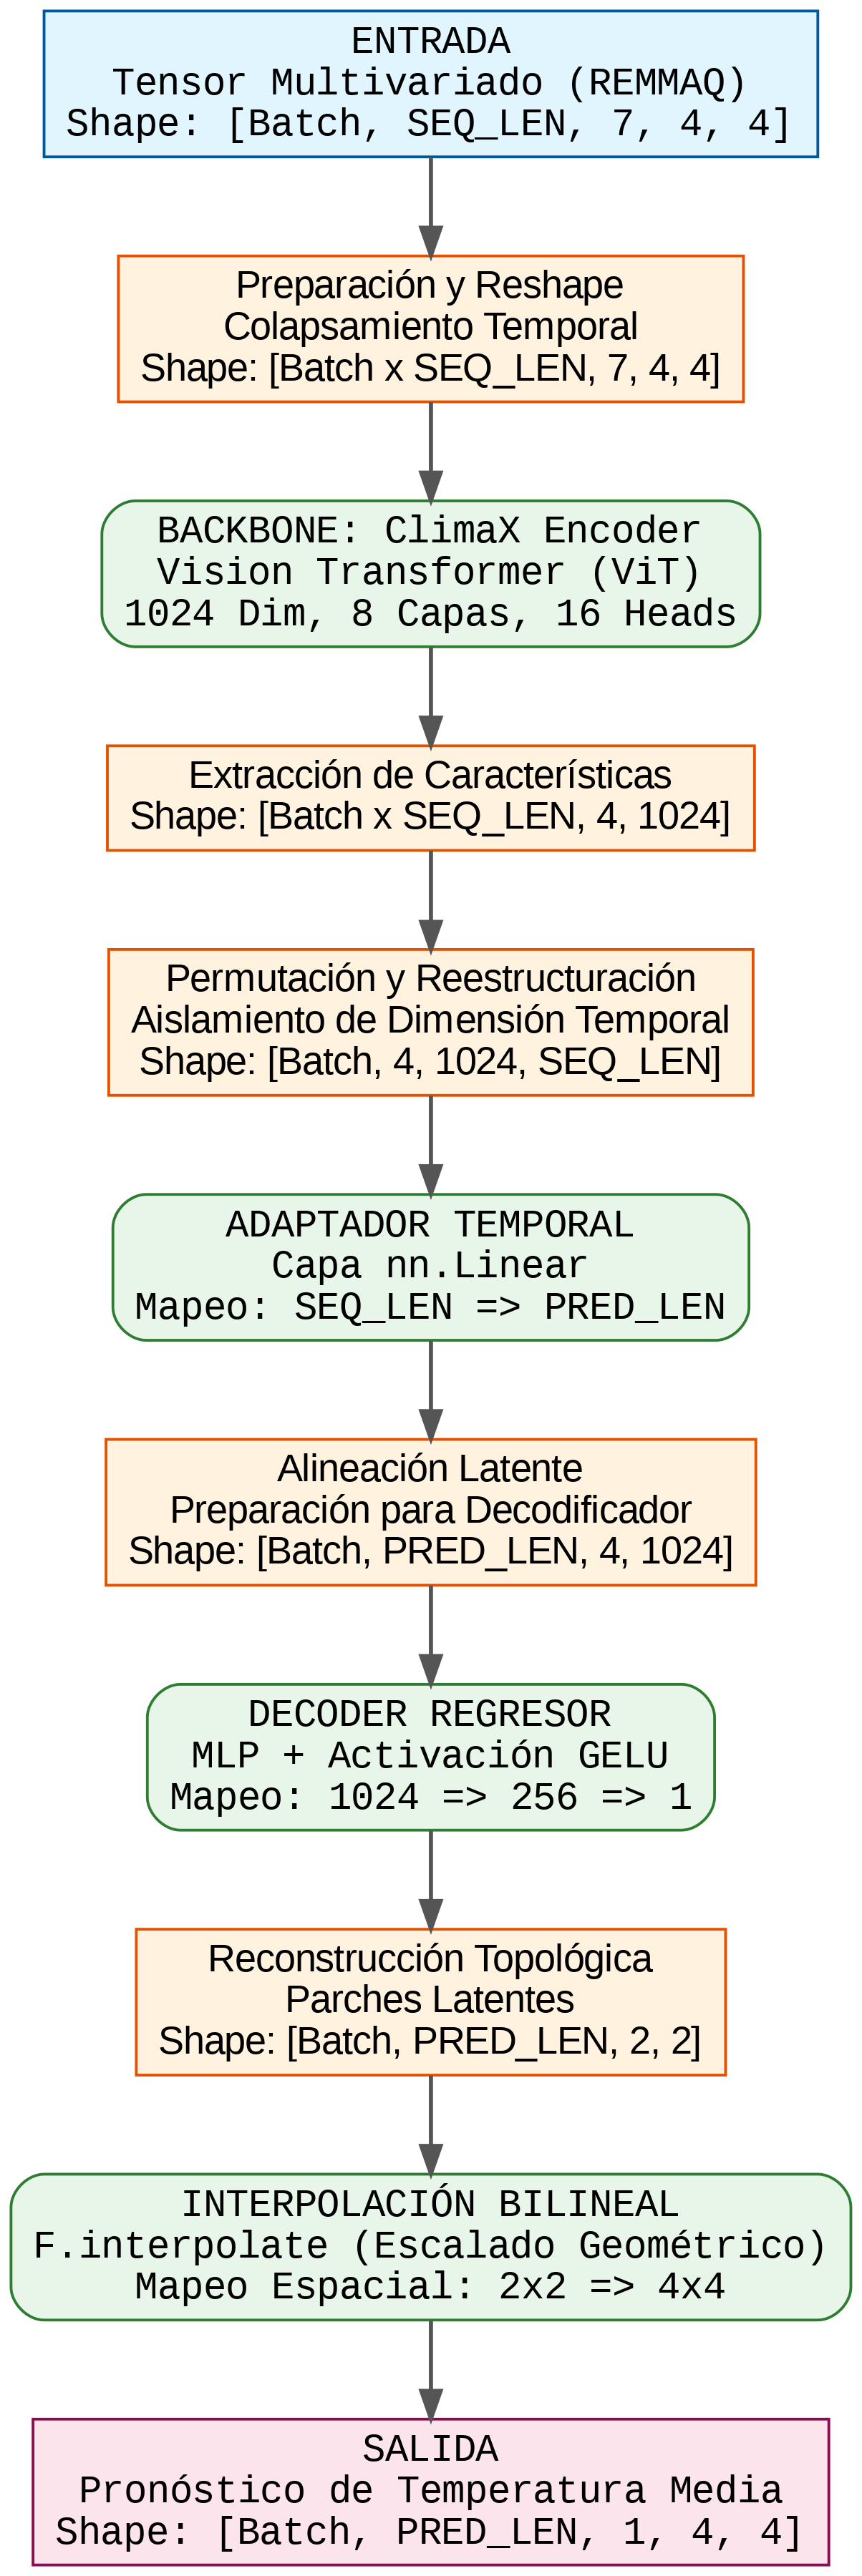

In [ ]:
import graphviz
from IPython.display import Image, display

# Crear el diagrama de arquitectura
dot = graphviz.Digraph(
    "ClimaX_Wrapper", comment="Arquitectura ClimaXFineTuningWrapper"
)
dot.attr(
    rankdir="TB",
    size="10,12",
    dpi="300",
    fontname="Arial",
    fontsize="12",
    bgcolor="white",
)

# Estilos de nodos por categoría
input_style = {
    "shape": "box",
    "style": "filled",
    "fillcolor": "#E1F5FE",
    "color": "#01579B",
    "fontname": "Arial-Bold",
}
process_style = {
    "shape": "box",
    "style": "filled",
    "fillcolor": "#FFF3E0",
    "color": "#E65100",
    "fontname": "Arial",
}
network_style = {
    "shape": "box",
    "style": "filled,rounded",
    "fillcolor": "#E8F5E9",
    "color": "#2E7D32",
    "fontname": "Arial-Bold",
}
output_style = {
    "shape": "box",
    "style": "filled",
    "fillcolor": "#FCE4EC",
    "color": "#880E4F",
    "fontname": "Arial-Bold",
}

# Definición de Nodos
dot.node(
    "A",
    "ENTRADA\nTensor Multivariado (REMMAQ)\nShape: [Batch, SEQ_LEN, 7, 4, 4]",
    **input_style,
)
dot.node(
    "B",
    "Preparación y Reshape\nColapsamiento Temporal\nShape: [Batch x SEQ_LEN, 7, 4, 4]",
    **process_style,
)
dot.node(
    "C",
    "BACKBONE: ClimaX Encoder\nVision Transformer (ViT)\n1024 Dim, 8 Capas, 16 Heads",
    **network_style,
)
dot.node(
    "D",
    "Extracción de Características\nShape: [Batch x SEQ_LEN, 4, 1024]",
    **process_style,
)
dot.node(
    "E",
    "Permutación y Reestructuración\nAislamiento de Dimensión Temporal\nShape: [Batch, 4, 1024, SEQ_LEN]",
    **process_style,
)
dot.node(
    "F",
    "ADAPTADOR TEMPORAL\nCapa nn.Linear\nMapeo: SEQ_LEN => PRED_LEN",
    **network_style,
)
dot.node(
    "G",
    "Alineación Latente\nPreparación para Decodificador\nShape: [Batch, PRED_LEN, 4, 1024]",
    **process_style,
)
dot.node(
    "H",
    "DECODER REGRESOR\nMLP + Activación GELU\nMapeo: 1024 => 256 => 1",
    **network_style,
)
dot.node(
    "I",
    "Reconstrucción Topológica\nParches Latentes\nShape: [Batch, PRED_LEN, 2, 2]",
    **process_style,
)
dot.node(
    "J",
    "INTERPOLACIÓN BILINEAL\nF.interpolate (Escalado Geométrico)\nMapeo Espacial: 2x2 => 4x4",
    **network_style,
)
dot.node(
    "K",
    "SALIDA\nPronóstico de Temperatura Media\nShape: [Batch, PRED_LEN, 1, 4, 4]",
    **output_style,
)

# Conexiones
edges = [
    ("A", "B"),
    ("B", "C"),
    ("C", "D"),
    ("D", "E"),
    ("E", "F"),
    ("F", "G"),
    ("G", "H"),
    ("H", "I"),
    ("I", "J"),
    ("J", "K"),
]
for u, v in edges:
    dot.edge(u, v, color="#555555", penwidth="1.5")

# Renderizar y guardar en el entorno de Colab
output_path = "/content/drive/My Drive/Experimentos/final/models/climax_finetuned/climax_arquitectura"
dot.render(output_path, format="png", cleanup=True)

print(f" Imagen generada y guardada exitosamente en: {output_path}.png")

# Mostrar la imagen directamente en la salida de la celda
display(Image(filename=f"{output_path}.png"))

✅ Imagen generada y guardada exitosamente en: /content/drive/My Drive/Experimentos/final/models/climax_finetuned/raf_arquitectura.png


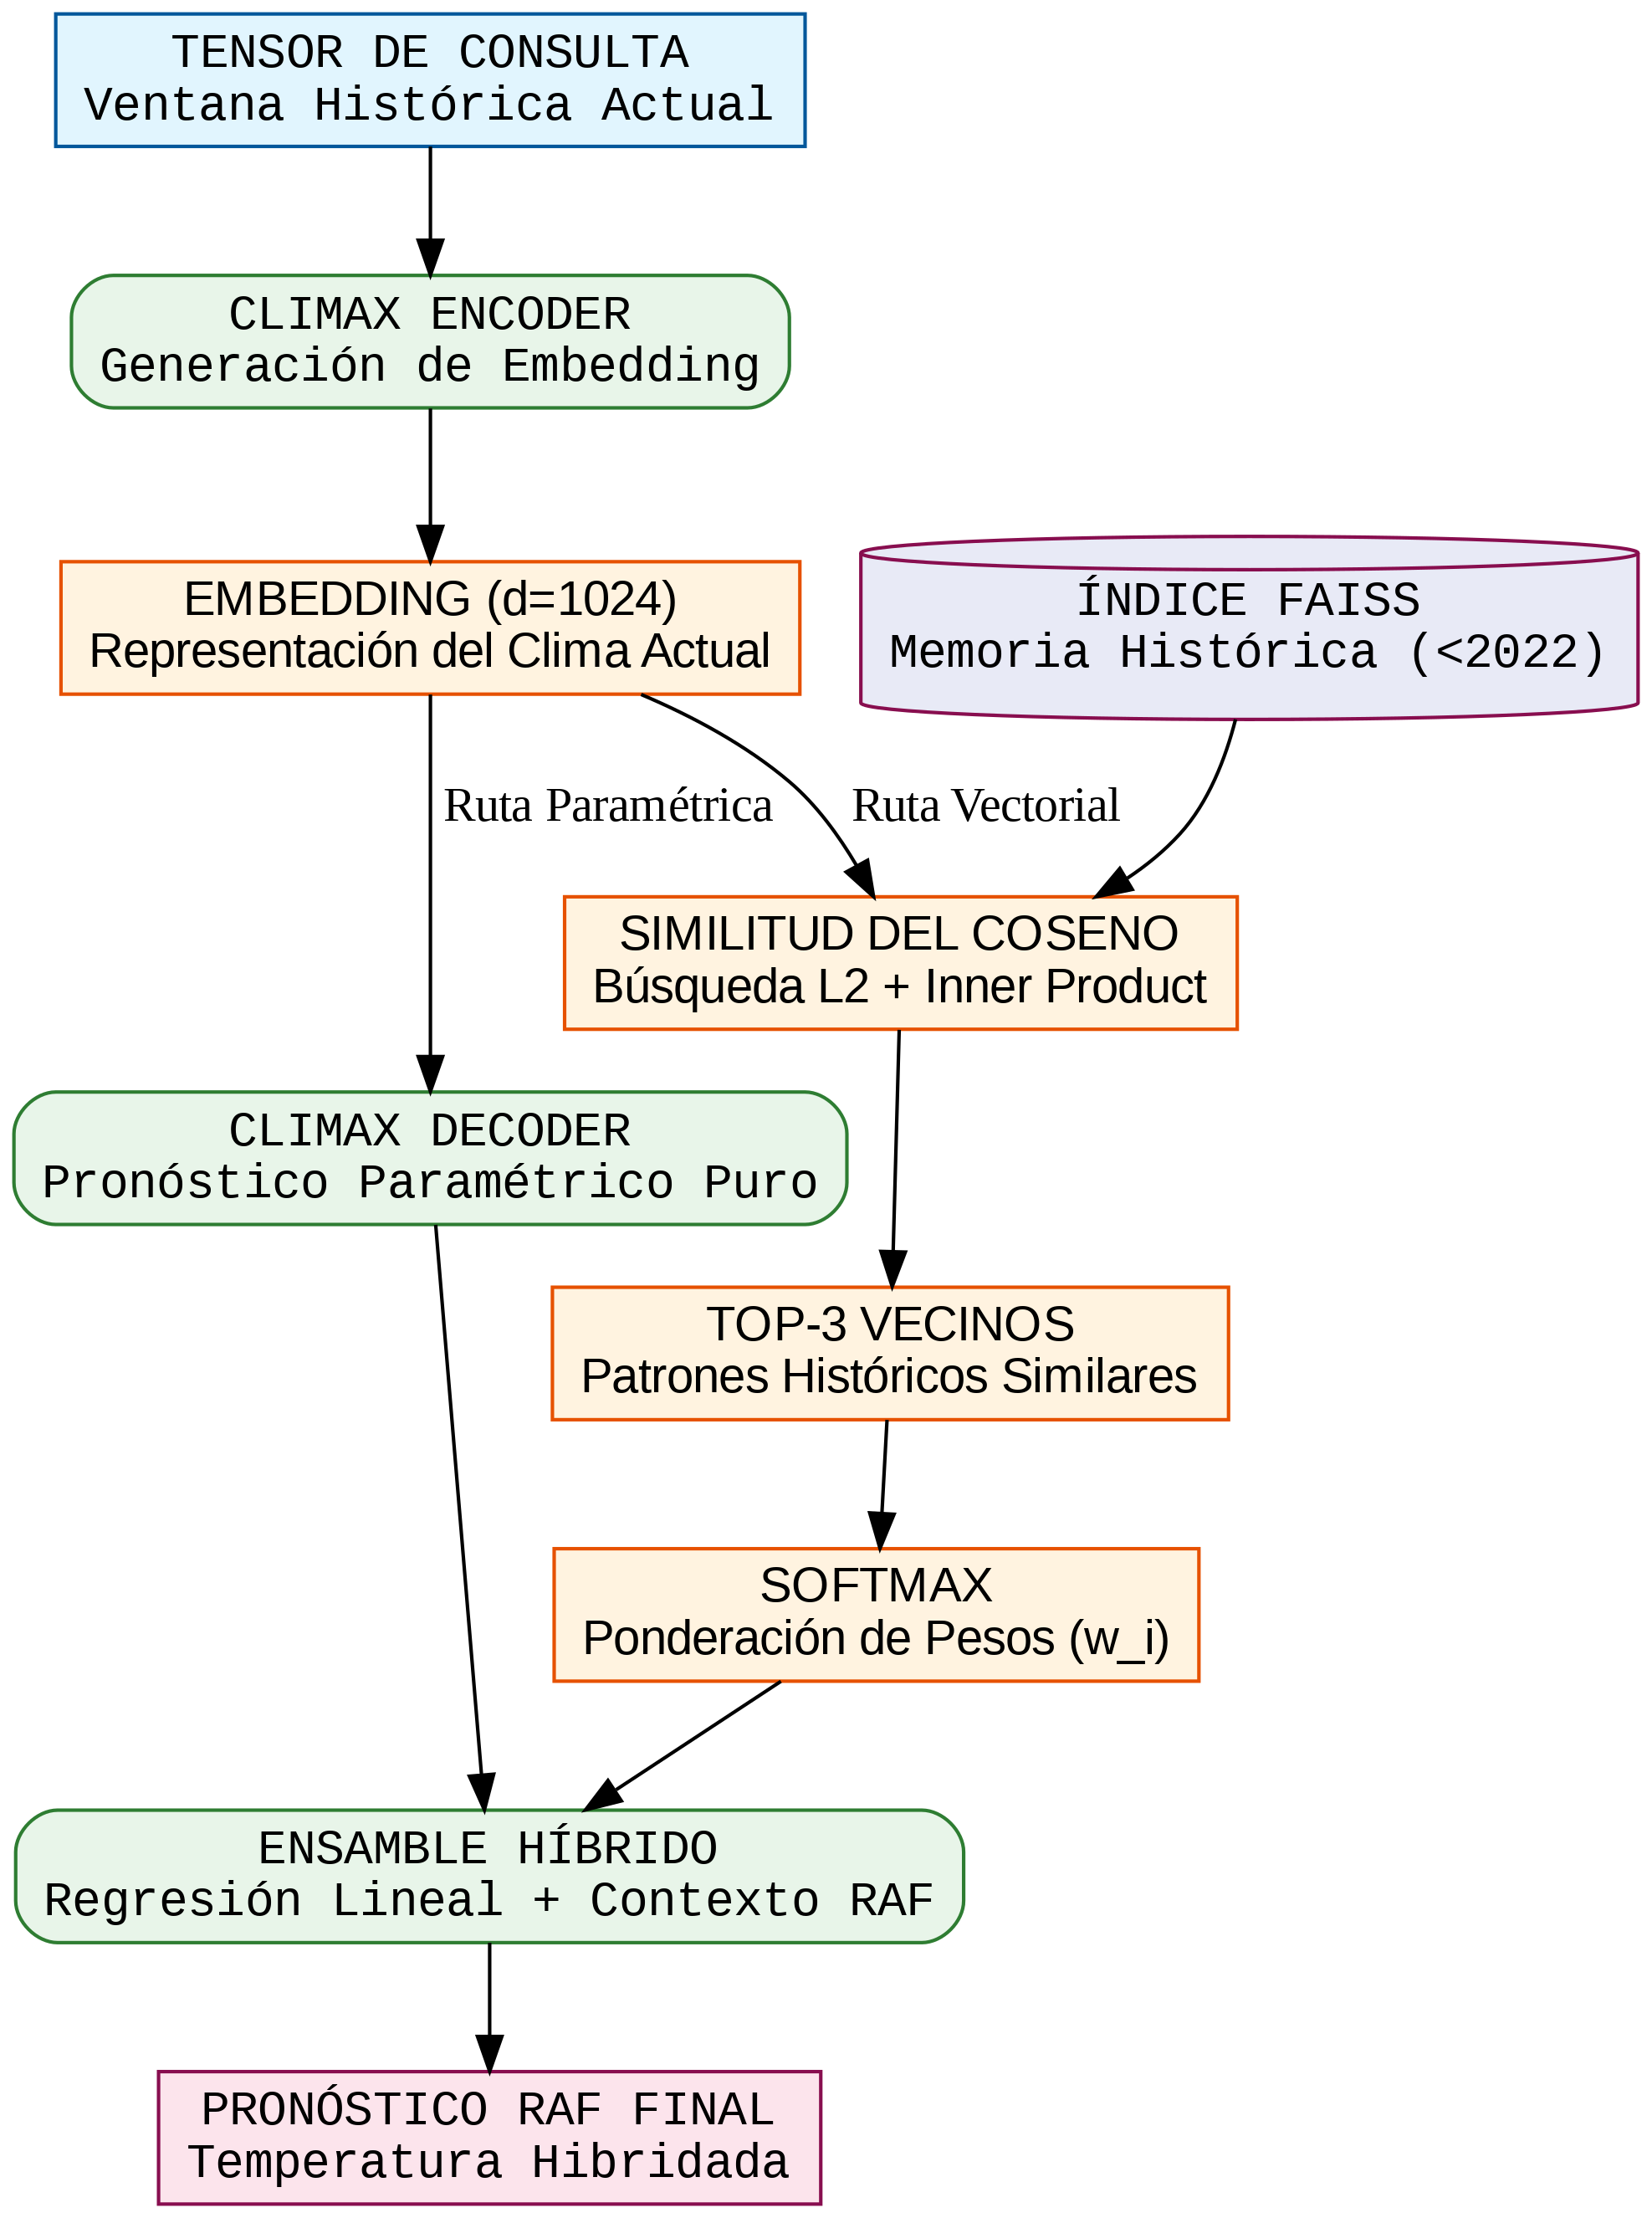

In [7]:
import graphviz
from IPython.display import Image, display

dot = graphviz.Digraph("RAF_Architecture", comment="Arquitectura RAF ClimaX")
dot.attr(rankdir="TB", size="10,12", dpi="300", fontname="Arial", fontsize="12", bgcolor="white")

# Estilos
input_style = {"shape": "box", "style": "filled", "fillcolor": "#E1F5FE", "color": "#01579B", "fontname": "Arial-Bold"}
process_style = {"shape": "box", "style": "filled", "fillcolor": "#FFF3E0", "color": "#E65100", "fontname": "Arial"}
db_style = {"shape": "cylinder", "style": "filled", "fillcolor": "#E8EAF6", "color": "#880E4F", "fontname": "Arial-Bold"}
model_style = {"shape": "box", "style": "filled,rounded", "fillcolor": "#E8F5E9", "color": "#2E7D32", "fontname": "Arial-Bold"}
output_style = {"shape": "box", "style": "filled", "fillcolor": "#FCE4EC", "color": "#880E4F", "fontname": "Arial-Bold"}

# Nodos
dot.node("A", "TENSOR DE CONSULTA\nVentana Histórica Actual", **input_style)
dot.node("B", "CLIMAX ENCODER\nGeneración de Embedding", **model_style)
dot.node("C", "EMBEDDING (d=1024)\nRepresentación del Clima Actual", **process_style)

# Rama Base Paramétrica
dot.node("D", "CLIMAX DECODER\nPronóstico Paramétrico Puro", **model_style)

# Rama RAF
dot.node("E", "ÍNDICE FAISS\nMemoria Histórica (<2022)", **db_style)
dot.node("F", "SIMILITUD DEL COSENO\nBúsqueda L2 + Inner Product", **process_style)
dot.node("G", "TOP-3 VECINOS\nPatrones Históricos Similares", **process_style)
dot.node("H", "SOFTMAX\nPonderación de Pesos (w_i)", **process_style)

# Hibridación
dot.node("I", "ENSAMBLE HÍBRIDO\nRegresión Lineal + Contexto RAF", **model_style)
dot.node("J", "PRONÓSTICO RAF FINAL\nTemperatura Hibridada", **output_style)

# Conexiones
dot.edge("A", "B")
dot.edge("B", "C")

dot.edge("C", "D", label=" Ruta Paramétrica")
dot.edge("C", "F", label=" Ruta Vectorial")

dot.edge("E", "F")
dot.edge("F", "G")
dot.edge("G", "H")

dot.edge("D", "I")
dot.edge("H", "I")

dot.edge("I", "J")

output_path = "/content/drive/My Drive/Experimentos/final/models/climax_finetuned/raf_arquitectura"
dot.render(output_path, format="png", cleanup=True)

print(f" Imagen generada y guardada exitosamente en: {output_path}.png")
display(Image(filename=f"{output_path}.png"))